# How to use an LLM via an API - Quickstart

**VERSION HISTORY - DON'T DELETE**

V1.0 - March 3, 2025 - Rama Ramakrishnan (if you see errors, please email ramar@mit.edu)

V2.0 - March 1, 2026 - Rama Ramakrishnan (if you see errors, please email ramar@mit.edu)

## Introduction

**LLM-based products, services and applications are all built using APIs**.


In this colab, we will show how to interact with an LLM using an API (rather than a web interface - e.g., https://chat.openai.com/). This is sometimes referred to as "programmatic access".


We will access the [OpenAI API](https://platform.openai.com/docs/overview) via the [`OpenAI` Python package](https://github.com/openai/openai-python).

While this colab uses the OpenAI API, the same *general* approach is applicable for working with the APIs of other LLM providers, with some minor code changes.

## Setup

The `openAI` Python package is pre-installed in colab so we can just use it directly.

In [ ]:
from openai import OpenAI

To use the API, you need an **API access key**. You can get it [here](https://platform.openai.com/api-keys) after creating an account.

Please note that you will be charged for using the API ([pricing](https://developers.openai.com/api/docs/pricing)).

We will use the `gpt-4o-mini` model. Its pricing is below. The requests we make in this colab should just cost a **fraction of a cent** in total.

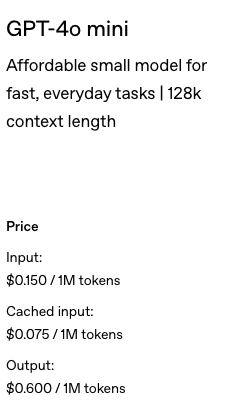

After you get your key, click on the 'key' icon on the left navbar and paste it as shown below:

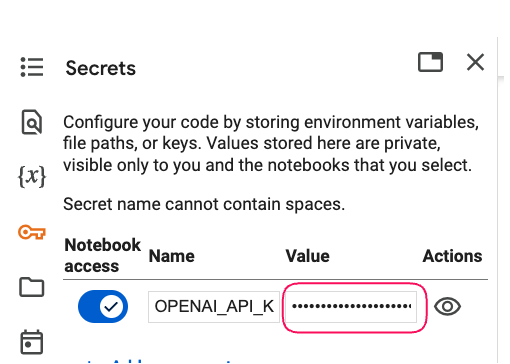

In [ ]:
from google.colab import userdata


client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

## Helper Functions

In [ ]:
def ask_the_LLM(prompt,
                model="gpt-4o-mini",
                max_tokens=40,
                temperature=0.0,
                top_p=1.0,
                logprobs=True,
                top_logprobs=10,
                seed=42):

    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "system", "content": "You are a helpful assistant."},
                  {"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
        logprobs=logprobs,
        top_logprobs=top_logprobs
    )
    return response

In [ ]:
def just_the_text(response):
  print(response.choices[0].message.content)

In [ ]:
import numpy as np

def get_text_and_probs(response):
  just_the_text(response)
  print("\n" + "-" * 80 + "\n")
  print("Softmax probabilities for the FIRST output token:")
  first_token_probs = response.choices[0].logprobs.content[0].top_logprobs
  for elem in first_token_probs:
        print(f"token={elem.token}, prob={np.exp(elem.logprob):.2%}")

## Examples

In [ ]:
just_the_text(ask_the_LLM("Write a limerick about the MIT Sloan course "
                          "Hands-on Deep Learning"))

At MIT, where bright minds convene,  
In Sloan's course, deep learning's the theme.  
With hands-on delight,  
They code day and night,  
Creating AI that's truly supreme


## The Effect of Sampling Parameters

We will investigate what happens if we vary the `top-p` and `temperature` parameters.

### Temperature

In [ ]:
just_the_text(ask_the_LLM("Write a limerick about MIT Sloan",
                          temperature=0.0))

At MIT Sloan, minds brightly shine,  
Where business and tech intertwine.  
With data and flair,  
They tackle with care,  
Creating the leaders of time!


Let's run it again. Since `temperature=0.0`, we are more likely to get the same output (i.e., it *should* behave deterministically) but this is **not** guaranteed due to some technical/hardware reasons.

In [ ]:
just_the_text(ask_the_LLM("Write a limerick about MIT Sloan",
                          temperature=0.0))

At MIT Sloan, minds brightly shine,  
Where business and tech intertwine.  
With data and flair,  
They tackle with care,  
Creating solutions divine!


The output from different runs can differ slightly, even when we set `temperature=0.0`.

Let's bump up temperature and see how it changes.

In [ ]:
just_the_text(ask_the_LLM("Write a limerick about MIT Sloan",
                          temperature=1.0))

At MIT Sloan, minds thrive and inspire,  
With innovation and dreams that won't tire.  
In the halls of bright thought,  
Business lessons are taught,  
As leaders ascend ever higher.  


Nice, but not surprising.

Now, let's see what happens if we crank it up to the upper limit. Recall what will happen: previously low-probability tokens will now become more probable.

In [ ]:
just_the_text(ask_the_LLM("Write a limerick about MIT Sloan",
                          temperature=2.0))

At MIT Sloan, minds gleam and grow,  
Where thinkers most forward will go.  
With sharp business ignite,  
Innovation takes flight,  
As pioneers Chart spirits pagalendere fame у building Indiana


🤔

### Top-p

If we focus on the tokens that represent the top 90% of the distribution using `top_p = 0.9` but still keep the `temperature=2.0`, maybe we can achieve a creative output that is not garbage?

In [ ]:
just_the_text(ask_the_LLM("Write a limerick about MIT Sloan",
                          temperature=2.0,
                          top_p=0.9))

At MIT Sloan, minds brilliantly blend,  
Where data and strategy trend,  
With theories and codes,  
They lighten the loads,  
Preparing great leaders to mend!


## Viewing Softmax Probabilities

In [ ]:
get_text_and_probs(ask_the_LLM("MIT Sloan students are some of the most"))

MIT Sloan students are some of the most innovative, analytical, and driven individuals in the field of business education. They are known for their strong quantitative skills, collaborative spirit, and a focus on solving real

--------------------------------------------------------------------------------

Softmax probabilities for the FIRST output token:
token=MIT, prob=99.84%
token=innov, prob=0.08%
token=int, prob=0.01%
token=mit, prob=0.01%
token=high, prob=0.01%
token=creative, prob=0.01%
token=tal, prob=0.00%
token=The, prob=0.00%
token=prest, prob=0.00%
token=successful, prob=0.00%


In [ ]:
get_text_and_probs(ask_the_LLM("Fill in the blank. "
                               "Respond only with the blank: "
                               "MIT Sloan students are some of the most BLANK"))

innovative

--------------------------------------------------------------------------------

Softmax probabilities for the FIRST output token:
token=innov, prob=97.96%
token=tal, prob=1.40%
token=dr, prob=0.31%
token=amb, prob=0.10%
token=motiv, prob=0.06%
token=int, prob=0.05%
token=dynamic, prob=0.03%
token=creative, prob=0.02%
token=in, prob=0.01%
token=innovation, prob=0.01%
